In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
enrollments = pd.read_csv("data/enrollments.csv")

/var/folders/1h/mbpl_dh56dz_jlrv79gffl9w0000gn/T/ipykernel_45996/436320562.py:1: DtypeWarning: Columns (0: latitude, 1: longitude) have mixed types. Specify dtype option on import or set low_memory=False.
  enrollments = pd.read_csv("data/enrollments.csv")


### Game Plan:
1. Inspect data to get a sense of what is in here.
2. Brainstorm to come up with investigation topic(s).
3. Perform any necessary data cleansing.
4. Perform analysis to see if there is evidence supporting hypothesis.

## 1. Inspect Data

In [5]:
enrollments.info()

<class 'pandas.DataFrame'>
RangeIndex: 161560 entries, 0 to 161559
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   country                 161560 non-null  str    
 1   countrycode             159698 non-null  str    
 2   region                  159698 non-null  str    
 3   incomegroup             159691 non-null  str    
 4   iau_id                  161553 non-null  str    
 5   iau_id1                 161553 non-null  str    
 6   eng_name                161553 non-null  str    
 7   orig_name               138446 non-null  str    
 8   foundedyr               161525 non-null  float64
 9   yrclosed                460 non-null     float64
 10  private01               161525 non-null  float64
 11  coordinates             138352 non-null  str    
 12  latitude                138352 non-null  object 
 13  longitude               138352 non-null  object 
 14  phd_granting            161525 

In [6]:
enrollments.head()

,country,countrycode,region,incomegroup,iau_id,iau_id1,eng_name,orig_name,foundedyr,yrclosed,...,divisions,total_fields,unique_fields,specialized,merger,noiau,year,students5_interpolated,students5_extrapolated,students5_estimated
0,"argentina""",ARG,Latin America and Caribbean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"italy""",ITA,Europe and Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"peru""",PER,Latin America and Caribbean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"peru""",PER,Latin America and Caribbean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"romania""",ROU,Europe and Central Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Thoughts
Ok, I see some issues right away. Country names aren't capitalized here, and there are weird characters. These first rows have NaN values in every column. 
I am going to try narrowing down the scope to see what the data looks like in a smaller domain. Let's look at just the US for now.

In [7]:
usa = enrollments[enrollments["countrycode"] == "USA"]

In [8]:
usa.head()

,country,countrycode,region,incomegroup,iau_id,iau_id1,eng_name,orig_name,foundedyr,yrclosed,...,divisions,total_fields,unique_fields,specialized,merger,noiau,year,students5_interpolated,students5_extrapolated,students5_estimated
98,united states,USA,North America,High income,GLUE-1734,GLUE-1734-1,Itt Technical Institute-Earth City,NaN,1936.0,2016.0,...,NaN,NaN,NaN,1.0,0.0,1.0,1975.0,NaN,522.0,522.0
99,united states,USA,North America,High income,GLUE-1734,GLUE-1734-1,Itt Technical Institute-Earth City,NaN,1936.0,2016.0,...,NaN,NaN,NaN,1.0,0.0,1.0,1980.0,NaN,643.0,643.0
100,united states,USA,North America,High income,GLUE-1734,GLUE-1734-1,Itt Technical Institute-Earth City,NaN,1936.0,2016.0,...,NaN,NaN,NaN,1.0,0.0,1.0,1985.0,790.0,790.0,790.0
101,united states,USA,North America,High income,GLUE-1734,GLUE-1734-1,Itt Technical Institute-Earth City,NaN,1936.0,2016.0,...,NaN,NaN,NaN,1.0,0.0,1.0,2000.0,856.0,856.0,856.0
102,united states,USA,North America,High income,GLUE-1734,GLUE-1734-1,Itt Technical Institute-Earth City,NaN,1936.0,2016.0,...,NaN,NaN,NaN,1.0,0.0,1.0,1990.0,956.0,956.0,956.0


### Some initial observations:
- `country` is lowercase in these first 5 rows. Unclear if that is consistent, but as long as `countrycode` is consistent, I can look at countries that way. TODO: Add function to standardize `countrycode` column.
- `foundedyr` and `yrclosed` are fields to look into in terms of dropping some data. If I want to look at trends across the full timeline, any institutions that opened after 1950 or closed before 2020 could potentially skew data in unexpected ways.
- There is nothing tracking overall population. This could be an interesting point to help shape a hypothesis.

## 2. Brainstorming
- Do I want to focus on a specific country or region?
- I feel like I know more about US history than I do about other areas. Maybe incorporate other countries in some analysis if I know there might be some connection between US events?
- What are some things that could impact enrollment numbers?
- Population. I assume the US population has increased steadily over time, but maybe not?
- The baby boom is something that likely had an impact. What years were the baby boom (I know it was after WW2).
- It looks like the baby boom peak was 1953-1957, with the end being the biggest year. So 18 years later, there was likely an increase in college enrollment.
- What else? War? Would war cause decreased numbers?
- Maybe not. How does the G.I. Bill work?
- Ok, it looks like it's possible there could be a surge in enrollment after wars due to the G.I. Bill.
- I remember the surge in enlistment immediately after 9/11. That means there could be an increase in veterans attending college after their service.
- Another thing that could impact enrollment is an increase in foreign students. What events could cause that?
- The collapse of the Soviet Union would be an interesting one to look at. Sudden open borders could lead to students attending college abroad.
- When was that? Early 90s? Yes, 1991. But it looks like they had started opening their borders a couple years before. 

## Hypothesis
### The rate of enrollment in US colleges and universities between 1950 and 2020 will have 3 distinct spikes:
  1. Around 1970 - 1975 due to the baby boom.
  2. Around 1990 - 1995 due to an influx of students from the former USSR.
  3. Around 2005 - 2010 due to veterans enrolling on the G.I. Bill.

### How to define a "spike":
My hunch is that overall enrollment actually increases from year to year anyway. So I would need to confirm a spike by looking at the rate of change.

## 3. Data Cleansing
- Which columns matter for this?
- `countrycode` to actually get the US institutions (and the Russian ones for the comparison on point 2).
- `iau_id` to be able to group/aggregate by institution.
- `year` to be able to group/aggregate by year.
- `students5_estimated` to get enrollment numbers.
- `foundedyr` and `yrclosed` to focus on instiutions that were open for the entire data range.

In [9]:
# Filter down to the relevant columns
enrollments_rel_cols = enrollments[["countrycode", "iau_id", "year", "students5_estimated", "foundedyr", "yrclosed"]].copy()

In [10]:
# Remove rows that don't meet criteria
enrollments_rel_cols_dropped_na = enrollments_rel_cols.dropna(subset=["countrycode", "iau_id", "year", "students5_estimated", "foundedyr"]).copy()
enrollments_cleaned = enrollments_rel_cols_dropped_na[(enrollments_rel_cols_dropped_na["foundedyr"] <= 1950) & (enrollments_rel_cols_dropped_na["yrclosed"].isna())].copy()

In [11]:
# Get US info
us_df = enrollments_cleaned[enrollments_cleaned["countrycode"] == "USA"].copy()

In [12]:
us_df.info()

<class 'pandas.DataFrame'>
Index: 14730 entries, 654 to 161542
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   countrycode          14730 non-null  str    
 1   iau_id               14730 non-null  str    
 2   year                 14730 non-null  float64
 3   students5_estimated  14730 non-null  float64
 4   foundedyr            14730 non-null  float64
 5   yrclosed             0 non-null      float64
dtypes: float64(4), str(2)
memory usage: 805.5 KB


## 4. Analysis
- I think it's worth looking at both mean and median. Mean is more susceptible to extreme outliers.
- I will include standard deviation or interquartile range in a graph.
- Percent change is a key feature of my predictions.
- It could be good to also look at whether most/all institutions increased or if there are a lot that have decreased enrollment as well.

In [13]:
# Start with mean and median
us_enrollment = (us_df.groupby("year")["students5_estimated"].agg(["mean", "median"]).reset_index())

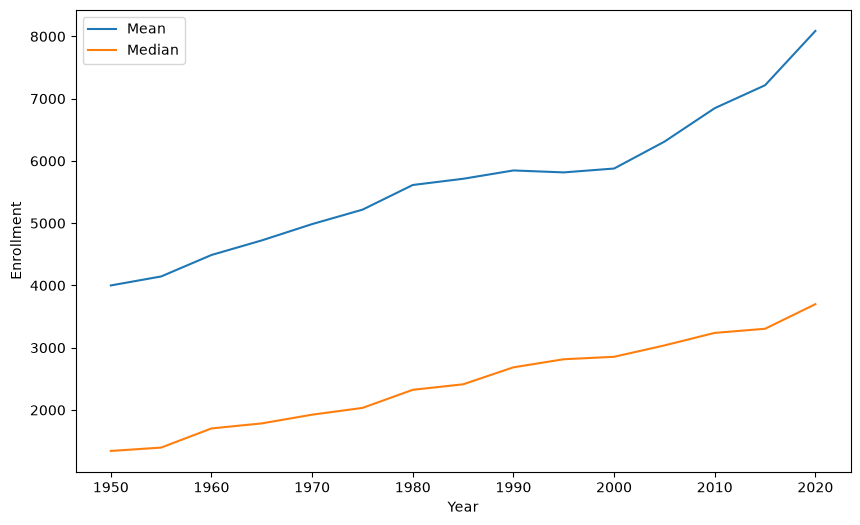

In [14]:
# Plot
plt.figure(figsize=(10,6))
plt.plot(us_enrollment["year"], us_enrollment["mean"], label="Mean")
plt.plot(us_enrollment["year"], us_enrollment["median"], label="Median")
plt.xlabel("Year")
plt.ylabel("Enrollment")
plt.legend()
plt.show()

### Observations:
- Both rise overall as predicted.
- The mean exhibits larger fluctuations than the median, suggesting that changes among relatively large institutions may be exerting greater influence on the average.

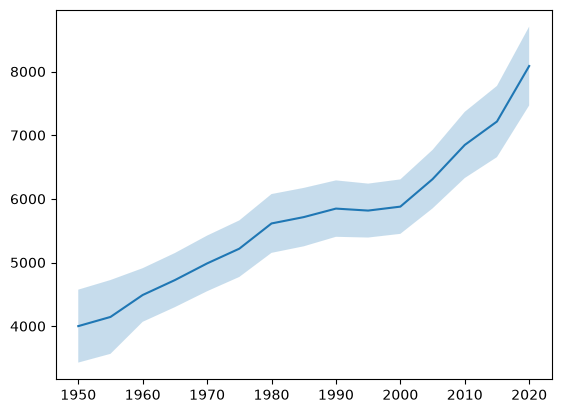

In [15]:
# Get confidence interval
stats = (us_df.groupby("year")["students5_estimated"].agg(["mean", "std", "count"]).reset_index())
# Standard error
stats["se"] = (stats["std"] /np.sqrt(stats["count"]))
# 95% confidence interval
stats["lower"] = (stats["mean"] - 1.96 * stats["se"])
stats["upper"] = (stats["mean"] + 1.96 * stats["se"])
# Plot
plt.plot(stats["year"], stats["mean"])
plt.fill_between(stats["year"], stats["lower"], stats["upper"], alpha=.25)
plt.show()

### Observations:
- The standard deviation remains relatively stable throughout the study period despite gradual increases in average enrollment.

<Figure size 1200x600 with 0 Axes>

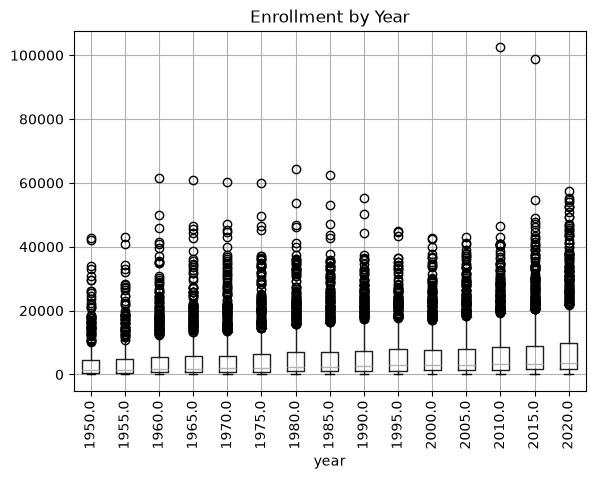

In [16]:
# Boxplot
plt.figure(figsize=(12,6))
us_df.boxplot(column="students5_estimated", by="year", rot=90)
plt.suptitle("")
plt.title("Enrollment by Year")
plt.show()

### Observations
- The spread is increasing, meaning variability in enrollement increases over time.
- The distribution is positively skewed, with a relatively small number of institutions exhibiting substantially larger enrollments than the majority. The upper tail of the distribution increases over time.
- These large institutions are outliers for every period though, so they are not a new phenomenon.

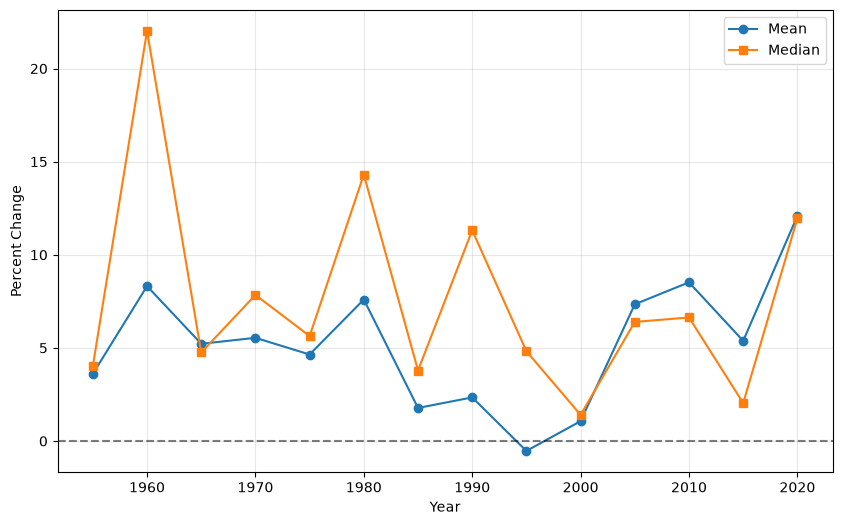

In [17]:
# Percent change
mean_by_year = us_df.groupby("year")["students5_estimated"].agg(["mean", "median"]).reset_index()
pct_change = mean_by_year.copy()
pct_change["mean"] = (pct_change["mean"].pct_change() * 100)
pct_change["median"] = (pct_change["median"].pct_change() * 100)
plt.figure(figsize=(10,6))
plt.plot(pct_change["year"], pct_change["mean"], marker="o", label="Mean")
plt.plot(pct_change["year"], pct_change["median"], marker="s", label="Median")
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observations:
- Mean and median enrollment both exhibit positive long-term growth, although the rate of growth varies considerably across periods.
- Growth slows substantially in the late 80s and 90s.
- There is a growth increase starting after 2000.

### Additional thought:
This is actually the percent change of the overall mean and median. I can also look at the meanand median of the percent change across all institutions.

In [18]:
# Create a new column for percent change
us_sorted = us_df.sort_values(["iau_id", "year"])
us_sorted["pct_change"] = (us_sorted.groupby("iau_id")["students5_estimated"].pct_change())

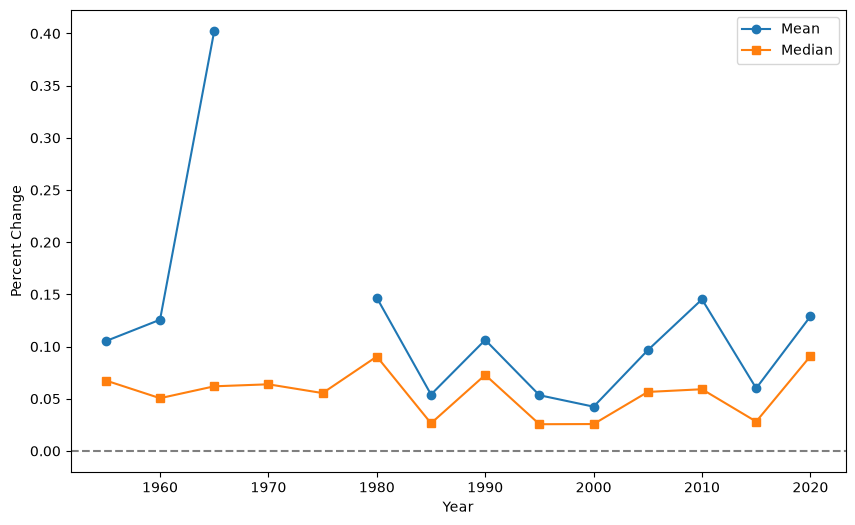

In [19]:
# Plot the mean
growth = us_sorted.groupby("year")["pct_change"].agg(["mean", "median"]).reset_index()
plt.figure(figsize=(10, 6))
plt.plot(growth["year"], growth["mean"], marker="o", label="Mean")
plt.plot(growth["year"], growth["median"], marker="s", label="Median")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.legend()
plt.show()

### Observsations:
- The results appear inconsistent with earlier analyses, suggesting a potential issue in the calculation.
- Investigating the source of the discrepancy.

In [20]:
print(growth.to_string())

      year      mean    median
0   1950.0       NaN       NaN
1   1955.0  0.105262  0.067487
2   1960.0  0.125727  0.050549
3   1965.0  0.402440  0.061934
4   1970.0       inf  0.063855
5   1975.0       inf  0.055437
6   1980.0  0.146746  0.090473
7   1985.0  0.054063  0.026505
8   1990.0  0.106366  0.072846
9   1995.0  0.053400  0.025609
10  2000.0  0.042424  0.025770
11  2005.0  0.096551  0.056541
12  2010.0  0.145262  0.059120
13  2015.0  0.060079  0.028147
14  2020.0  0.128912  0.090836


In [21]:
us_sorted[np.isinf(us_sorted["pct_change"])]

,countrycode,iau_id,year,students5_estimated,foundedyr,yrclosed,pct_change
4068,USA,IAU-000901,1975.0,2.0,1858.0,NaN,inf
87994,USA,IAU-014230,1970.0,1.0,1886.0,NaN,inf


That explains it. `inf` needs to be fixed. This is due to cases where the previous year was 0, so divide-by-0 errors.

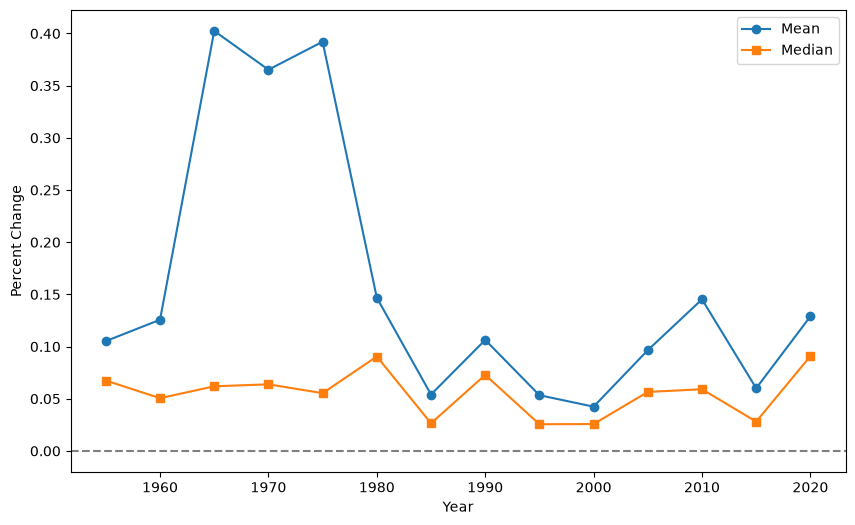

In [22]:
# Fix
growth = us_sorted[np.isfinite(us_sorted["pct_change"])].groupby("year")["pct_change"].agg(["mean", "median"]).reset_index()
plt.figure(figsize=(10, 6))
plt.plot(growth["year"], growth["mean"], marker="o", label="Mean")
plt.plot(growth["year"], growth["median"], marker="s", label="Median")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.legend()
plt.show()

### Observations
- Calculating percent change at the institution level yields a different pattern than calculating the percent change of aggregate statistics..
- This indicates some extreme outliers that were impacting the other graph.
- The biggest spike is now between 1960 and 1965, and this holds through 1975, before a drop again in 1980.

## Conclusions
## Original hypotheses
1. Around 1970 - 1975 due to the baby boom.
   - The analysis provides evidence consistent with this hypothesis.
2. Around 1990 - 1995 due to an influx of students from the former USSR.
   - This is not supported by the data.
   - If anything, this period saw slower growth.
   - And keeping in mind the percent change of overall mean, there is evidence supporting the opposite of my hypothesis 😅
3. Around 2005 - 2010 due to veterans enrolling on the G.I. Bill.
   - There is some minimal evidence to support this, but it is not the extreme spike I would have expected.
  
### Limitations
This analysis is exploratory in nature. While several temporal patterns are observed, the methods used here identify associations rather than causal relationships. Additional modeling and external covariates would be required to evaluate causal explanations.

## GDP Analysis

In [23]:
gdp_df = pd.read_csv("data/Countries GDP 1960-2020.csv")

In [24]:
gdp_df.head()

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Africa Eastern and Southern,AFE,1.931311e+10,1.972349e+10,2.149392e+10,2.573321e+10,2.352744e+10,2.681057e+10,2.915216e+10,3.017317e+10,...,9.430000e+11,9.510000e+11,9.640000e+11,9.850000e+11,9.200000e+11,8.730000e+11,9.850000e+11,1.010000e+12,1.010000e+12,9.210000e+11
1,Africa Western and Central,AFW,1.040428e+10,1.112805e+10,1.194335e+10,1.267652e+10,1.383858e+10,1.486247e+10,1.583285e+10,1.442643e+10,...,6.710000e+11,7.280000e+11,8.210000e+11,8.650000e+11,7.610000e+11,6.910000e+11,6.840000e+11,7.420000e+11,7.950000e+11,7.850000e+11
2,Australia,AUS,1.860679e+10,1.968306e+10,1.992272e+10,2.153993e+10,2.380110e+10,2.597715e+10,2.730989e+10,3.044462e+10,...,1.400000e+12,1.550000e+12,1.580000e+12,1.470000e+12,1.350000e+12,1.210000e+12,1.330000e+12,1.430000e+12,1.390000e+12,1.330000e+12
3,Austria,AUT,6.592694e+09,7.311750e+09,7.756110e+09,8.374175e+09,9.169984e+09,9.994071e+09,1.088768e+10,1.157943e+10,...,4.310000e+11,4.090000e+11,4.300000e+11,4.420000e+11,3.820000e+11,3.960000e+11,4.160000e+11,4.550000e+11,4.450000e+11,4.330000e+11
4,Burundi,BDI,1.960000e+08,2.030000e+08,2.135000e+08,2.327500e+08,2.607500e+08,1.589950e+08,1.654446e+08,1.782971e+08,...,2.235821e+09,2.333308e+09,2.451625e+09,2.705783e+09,3.104395e+09,2.732809e+09,2.748180e+09,2.668496e+09,2.631434e+09,2.841786e+09


### Observation
This needs to be "melted" to turn it in the right direction to merge.

In [25]:
gdp_melted = gdp_df.melt(id_vars=["Country Name", "Country Code"], var_name="year", value_name="gdp")

In [26]:
gdp_melted.head()

,Country Name,Country Code,year,gdp
0,Africa Eastern and Southern,AFE,1960,1.931311e+10
1,Africa Western and Central,AFW,1960,1.040428e+10
2,Australia,AUS,1960,1.860679e+10
3,Austria,AUT,1960,6.592694e+09
4,Burundi,BDI,1960,1.960000e+08


In [27]:
gdp_melted.info()

<class 'pandas.DataFrame'>
RangeIndex: 7320 entries, 0 to 7319
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  7320 non-null   str    
 1   Country Code  7320 non-null   str    
 2   year          7320 non-null   str    
 3   gdp           7319 non-null   float64
dtypes: float64(1), str(3)
memory usage: 228.9 KB


### Observsations
- `year` is a string here, so that needs to be converted before merging.
- I've only kept `countrycode` from the enrollment set, so I can drop `Country Name` here.
- It will be easier if I rename `Country Code` to match the column name in the enrollment dataframe.

In [28]:
gdp_melted["year"] = gdp_melted["year"].astype(float)

In [29]:
gdp_melted.rename(columns={'Country Code': 'countrycode'}, inplace=True)

In [30]:
# Merge
enrollment_gdp_merged = enrollments_cleaned.merge(gdp_melted, on=["countrycode", "year"], how="left")

In [31]:
enrollment_gdp_merged.head()

,countrycode,iau_id,year,students5_estimated,foundedyr,yrclosed,Country Name,gdp
0,PHL,IAU-000002,1960.0,733.0,1918.0,NaN,Philippines,7.515887e+09
1,PHL,IAU-000002,1965.0,966.0,1918.0,NaN,Philippines,6.517305e+09
2,PHL,IAU-000002,1970.0,1517.0,1918.0,NaN,Philippines,7.559180e+09
3,PHL,IAU-000002,1975.0,2217.0,1918.0,NaN,Philippines,1.687524e+10
4,PHL,IAU-000002,1980.0,2611.0,1918.0,NaN,Philippines,3.684824e+10


In [32]:
# Check for any missing values
print(enrollment_gdp_merged["gdp"].isna().sum())

19051


In [33]:
enrollment_gdp_merged[enrollment_gdp_merged["gdp"].isna()].head()

,countrycode,iau_id,year,students5_estimated,foundedyr,yrclosed,Country Name,gdp
13,DNK,IAU-000015,1955.0,117.0,1903.0,NaN,NaN,NaN
14,DNK,IAU-000015,1960.0,133.0,1903.0,NaN,NaN,NaN
15,DNK,IAU-000015,1970.0,142.0,1903.0,NaN,NaN,NaN
16,DNK,IAU-000015,1965.0,174.0,1903.0,NaN,NaN,NaN
17,DNK,IAU-000015,1975.0,315.0,1903.0,NaN,NaN,NaN


In [34]:
enrollment_cc = set(enrollment_gdp_merged["countrycode"])
gdp_cc = set(gdp_melted["countrycode"])
print(f"Count of enrollment countrycode: {len(enrollment_cc)}")
print(f"Count of gdp countrycode: {len(gdp_cc)}")

Count of enrollment countrycode: 120
Count of gdp countrycode: 120


In [35]:
len(enrollment_cc - gdp_cc)

58

In [36]:
# Ok, it looks like there are some differences, but at least one difference is capitalization
gdp_melted['countrycode'] = gdp_melted['countrycode'].str.upper()
# Merge again
enrollment_gdp_merged = enrollments_cleaned.merge(gdp_melted, on=["countrycode", "year"], how="left")

In [37]:
# Check missing values again
print(enrollment_gdp_merged["gdp"].isna().sum())

18870


Smaller at least. Observations with missing values will be excluded from analyses.

In [38]:
enrollment_gdp_merged.dropna(subset=['gdp'], inplace=True)

Let's see what the enrollment vs. gdp looks like

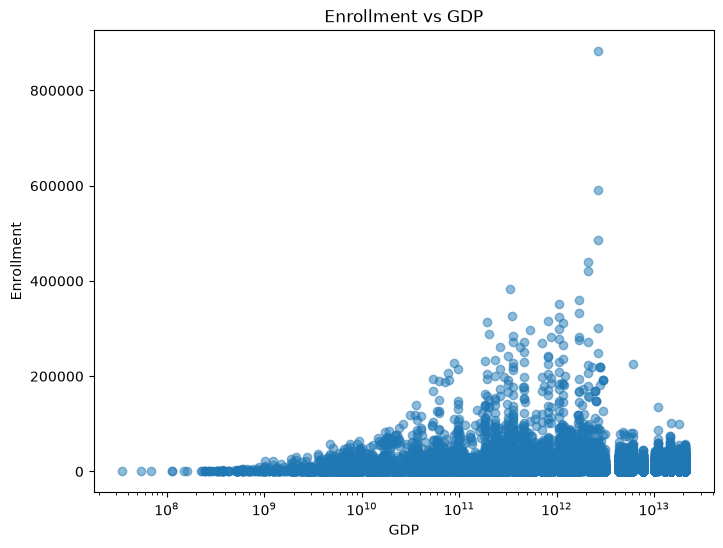

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(enrollment_gdp_merged["gdp"], enrollment_gdp_merged["students5_estimated"], alpha=0.5)
plt.xscale("log")  # GDP is huge, so this is cleaner
plt.xlabel("GDP")
plt.ylabel("Enrollment")
plt.title("Enrollment vs GDP")
plt.show()

In [40]:
enrollment_gdp_merged[["gdp", "students5_estimated"]].corr()

,gdp,students5_estimated
gdp,1.000000,0.007885
students5_estimated,0.007885,1.000000


No meaningful linear association was observed between GDP and enrollment (Pearson correlation ≈ 0.008). This suggests that GDP alone is unlikely to be a useful predictor of enrollment across countries without accounting for additional factors such as country-specific effects, population size, or demographic characteristics.

Because the data contain repeated observations across countries and years, a pooled correlation may obscure country-specific relationships. A natural extension would be to compute within-country correlations or fit a regression model with country fixed effects.